In [12]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path0315 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_cargo_radius0.315')
path059 = Path('/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5_cargo_radius0.59')

rs = [0.315, 0.59]

def get_local(path):
    seeds = sorted(list(path.glob('seed*.zarr')))

    cps = []
    ccs = []

    lps = []
    lcs = []

    for seed in seeds:
        cp_path = seed / "center_polar.zarr"
        cc_path = seed / "center_counts.zarr"

        cp_data = zarr.open_array(cp_path, mode='r')[:]
        cc_data = zarr.open_array(cc_path, mode='r')[:]

        cps.append(cp_data)
        ccs.append(cc_data)

        lp_path = seed / "local_polar.zarr"
        lc_path = seed / "counts.zarr"
        
        lp_data = zarr.open_array(lp_path, mode='r')[:]
        lc_data = zarr.open_array(lc_path, mode='r')[:]
        

        lps.append(lp_data)
        lcs.append(lc_data)

    cps = np.array(cps)
    ccs = np.array(ccs)
    lps = np.array(lps)
    lcs = np.array(lcs)

    thresholds_path = seed / "thresholds.zarr"
    threshold = zarr.open_array(thresholds_path, mode='r')[:]

    return cps, ccs, lps, lcs, threshold

Acps, Accs, Alps, Alcs = [], [], [], []

for path in [path0315, path059]:
    cps, ccs, lps, lcs, threshold = get_local(path)
    print(cps.shape)
    Acps.append(cps)
    Accs.append(ccs)
    Alps.append(lps)
    Alcs.append(lcs)

plt.style.use('../../my_style.mplstyle')

(131, 10000, 101)
(201, 10000, 101)


[Text(0.5, 0, 'threshold $\\hat{R}$'), Text(0, 0.5, 'polar order')]

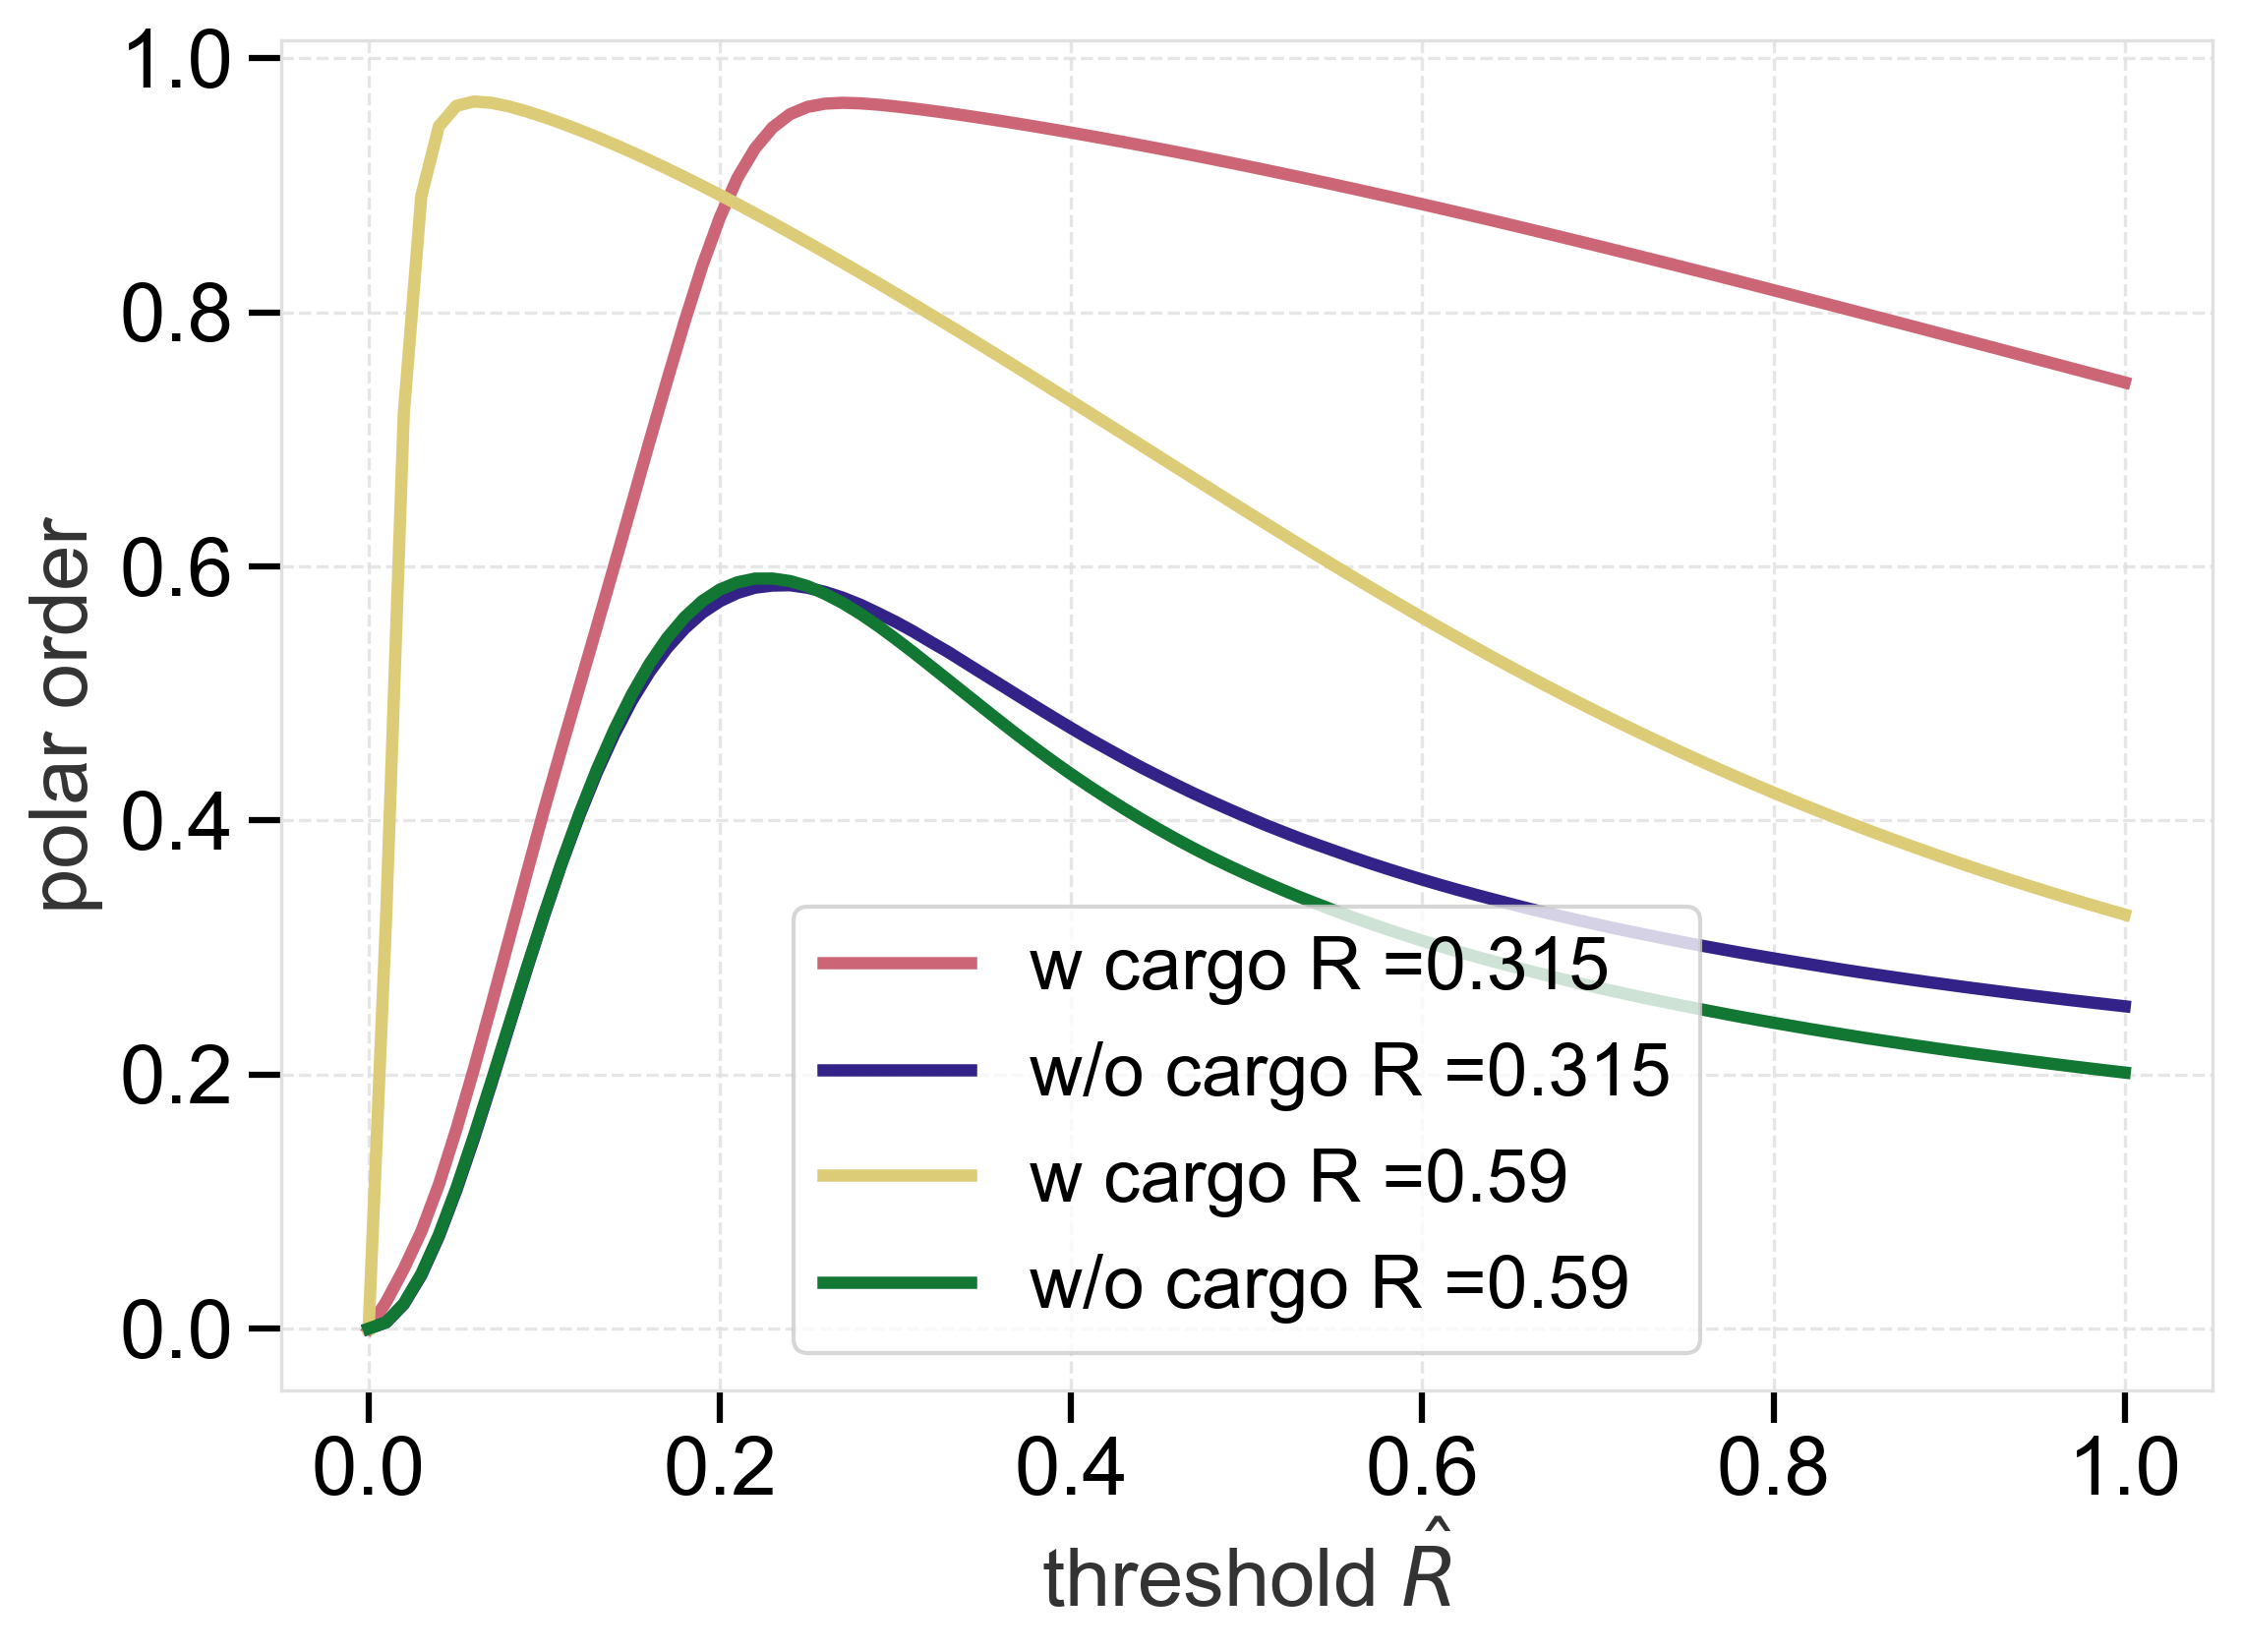

In [ ]:
fig, ax = plt.subplots()

for i in range(2):
       lpM = np.mean(Alps[i], axis = (0, 1))
       cpM = np.mean(Acps[i], axis = (0, 1))
       ax.plot(threshold, lpM, label = f'w cargo R ={rs[i]}')
       ax.plot(threshold, cpM, label = f'w/o cargo R ={rs[i]}')

ax.legend()

ax.set(xlabel = 'threshold $\hat{R}$',
       ylabel = 'polar order')

[Text(0.5, 0, 'threshold $\\hat{R}$'), Text(0, 0.5, 'counts')]

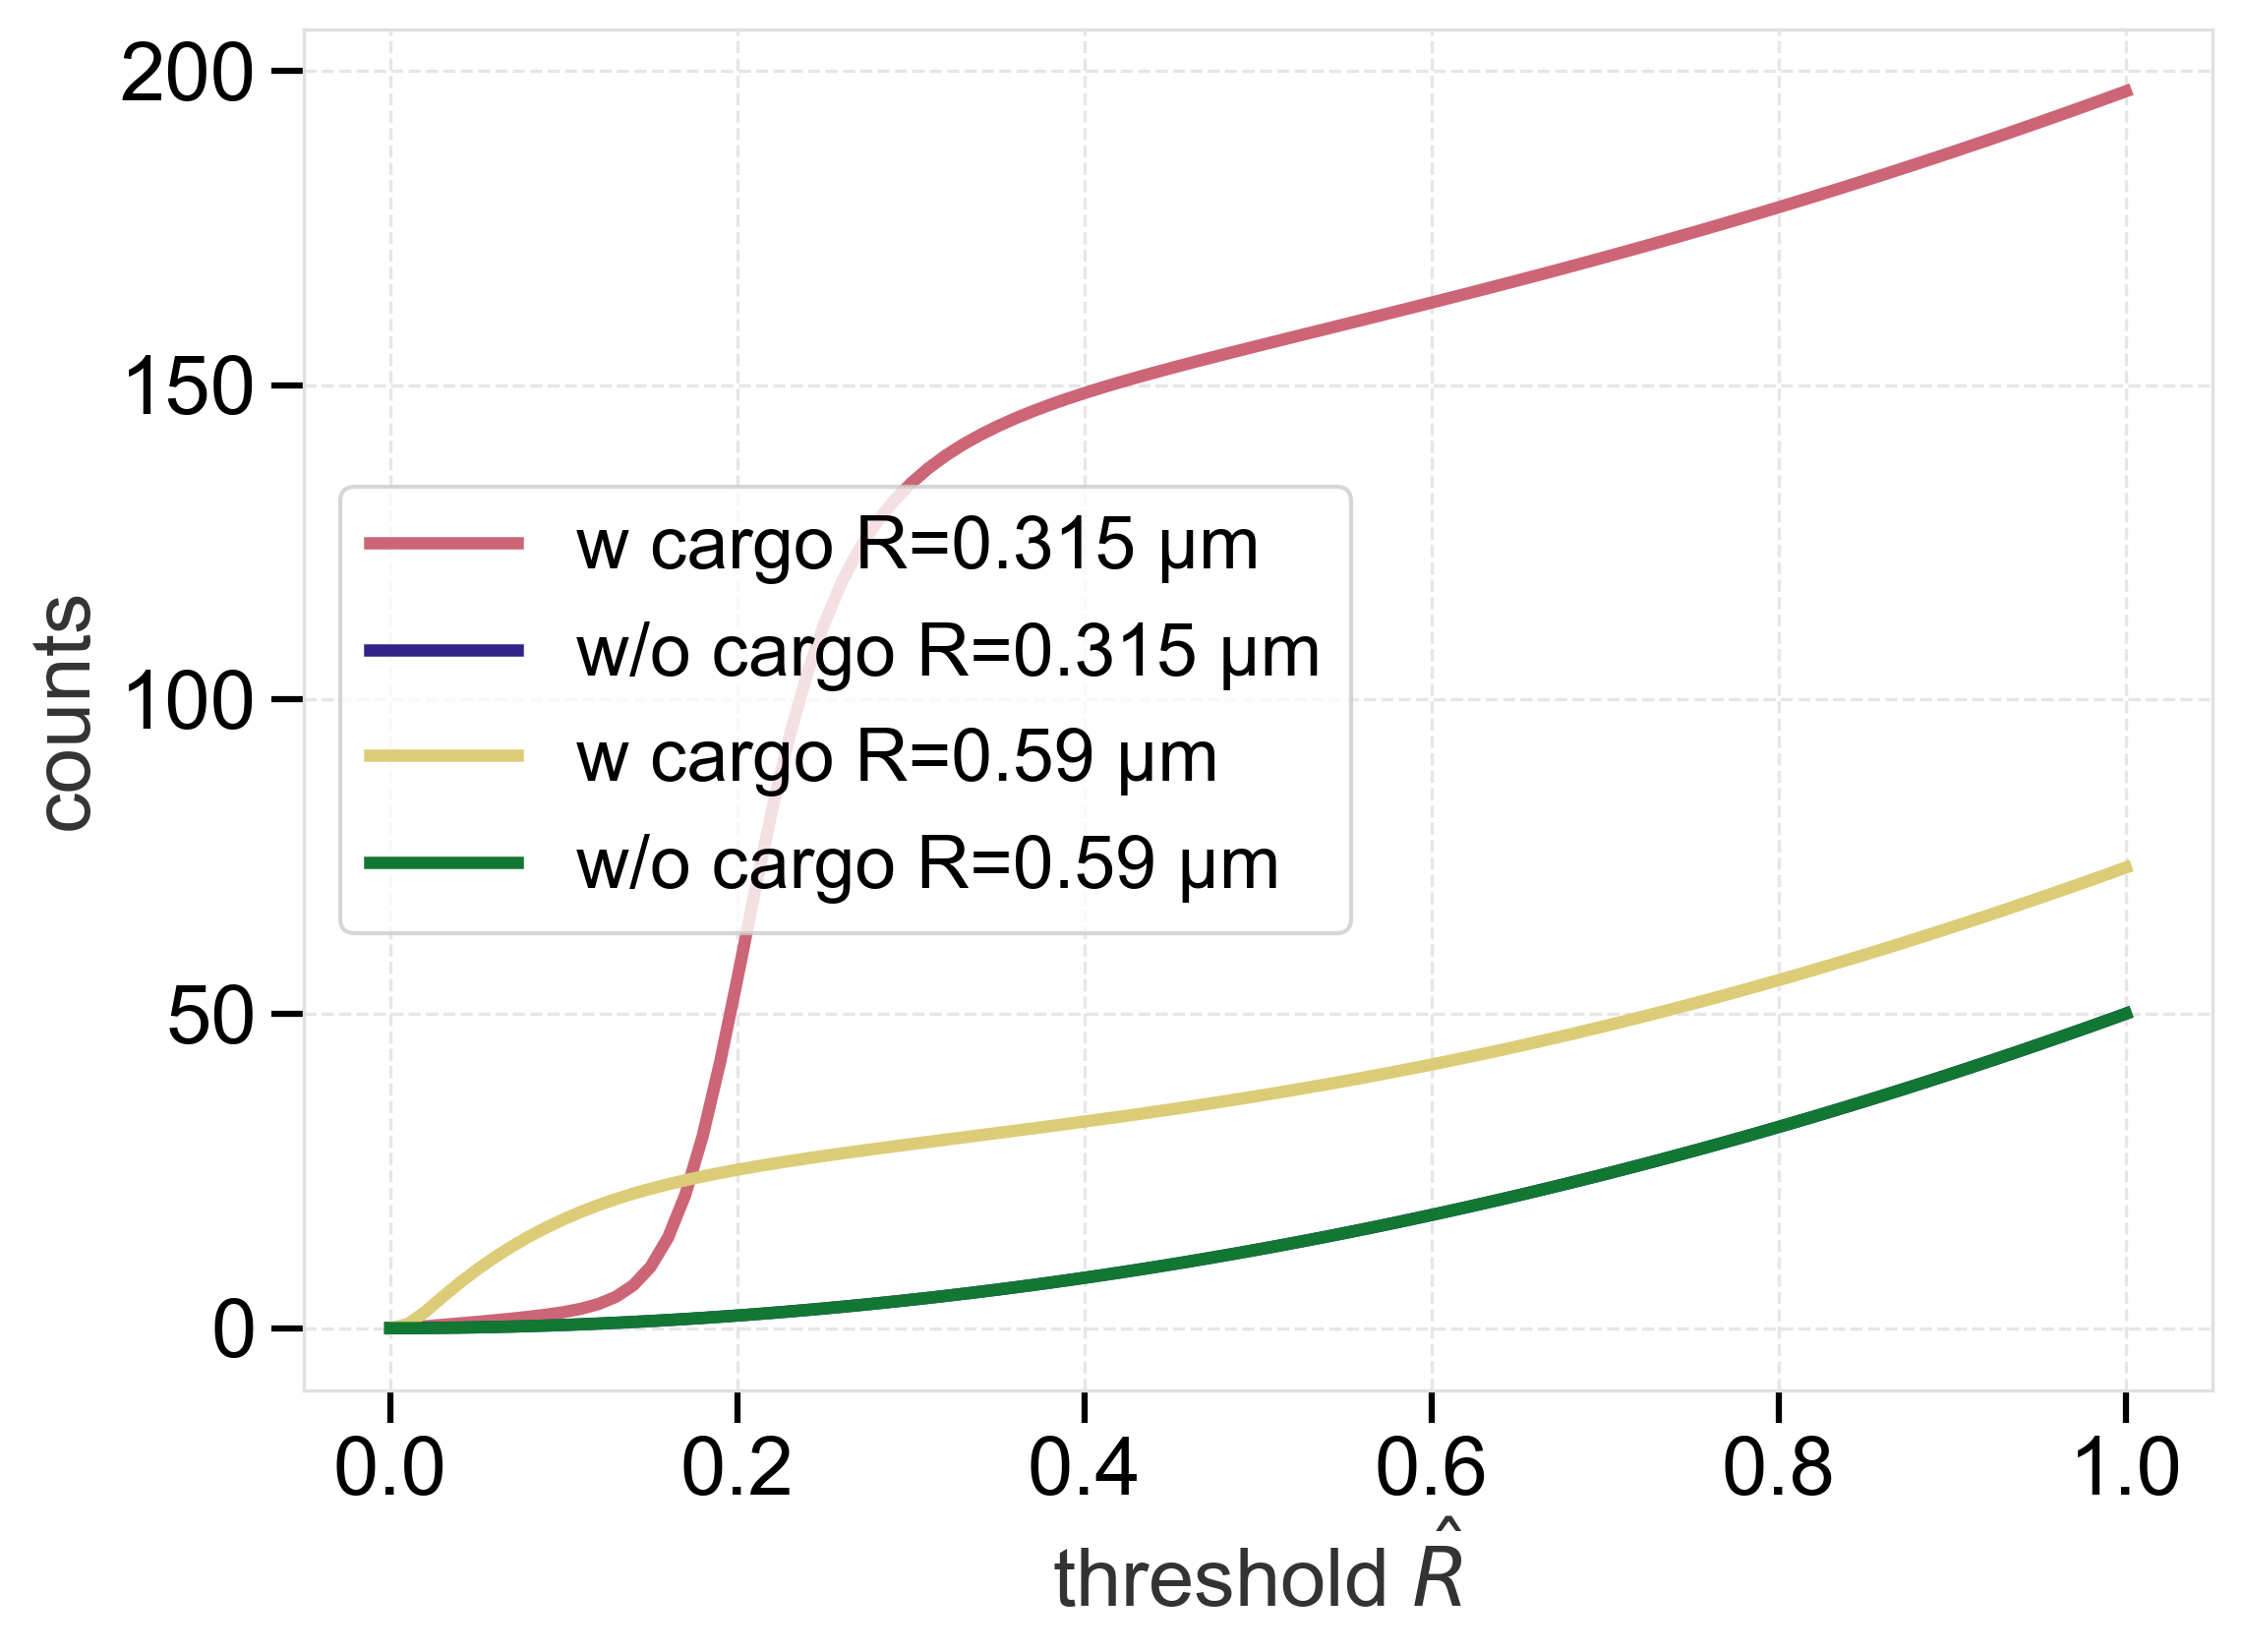

In [16]:
fig, ax = plt.subplots()

for i in range(2):
       lcM = np.mean(Alcs[i], axis = (0, 1))
       ccM = np.mean(Accs[i], axis = (0, 1))
       ax.plot(threshold, lcM, label = f'w cargo R={rs[i]} \u03bcm')
       ax.plot(threshold, ccM, label = f'w/o cargo R={rs[i]} \u03bcm')

ax.legend()

ax.set(xlabel = 'threshold $\hat{R}$',
       ylabel = 'counts')

[Text(0.5, 0, 'threshold $\\hat{R}$'), Text(0, 0.5, 'counts')]

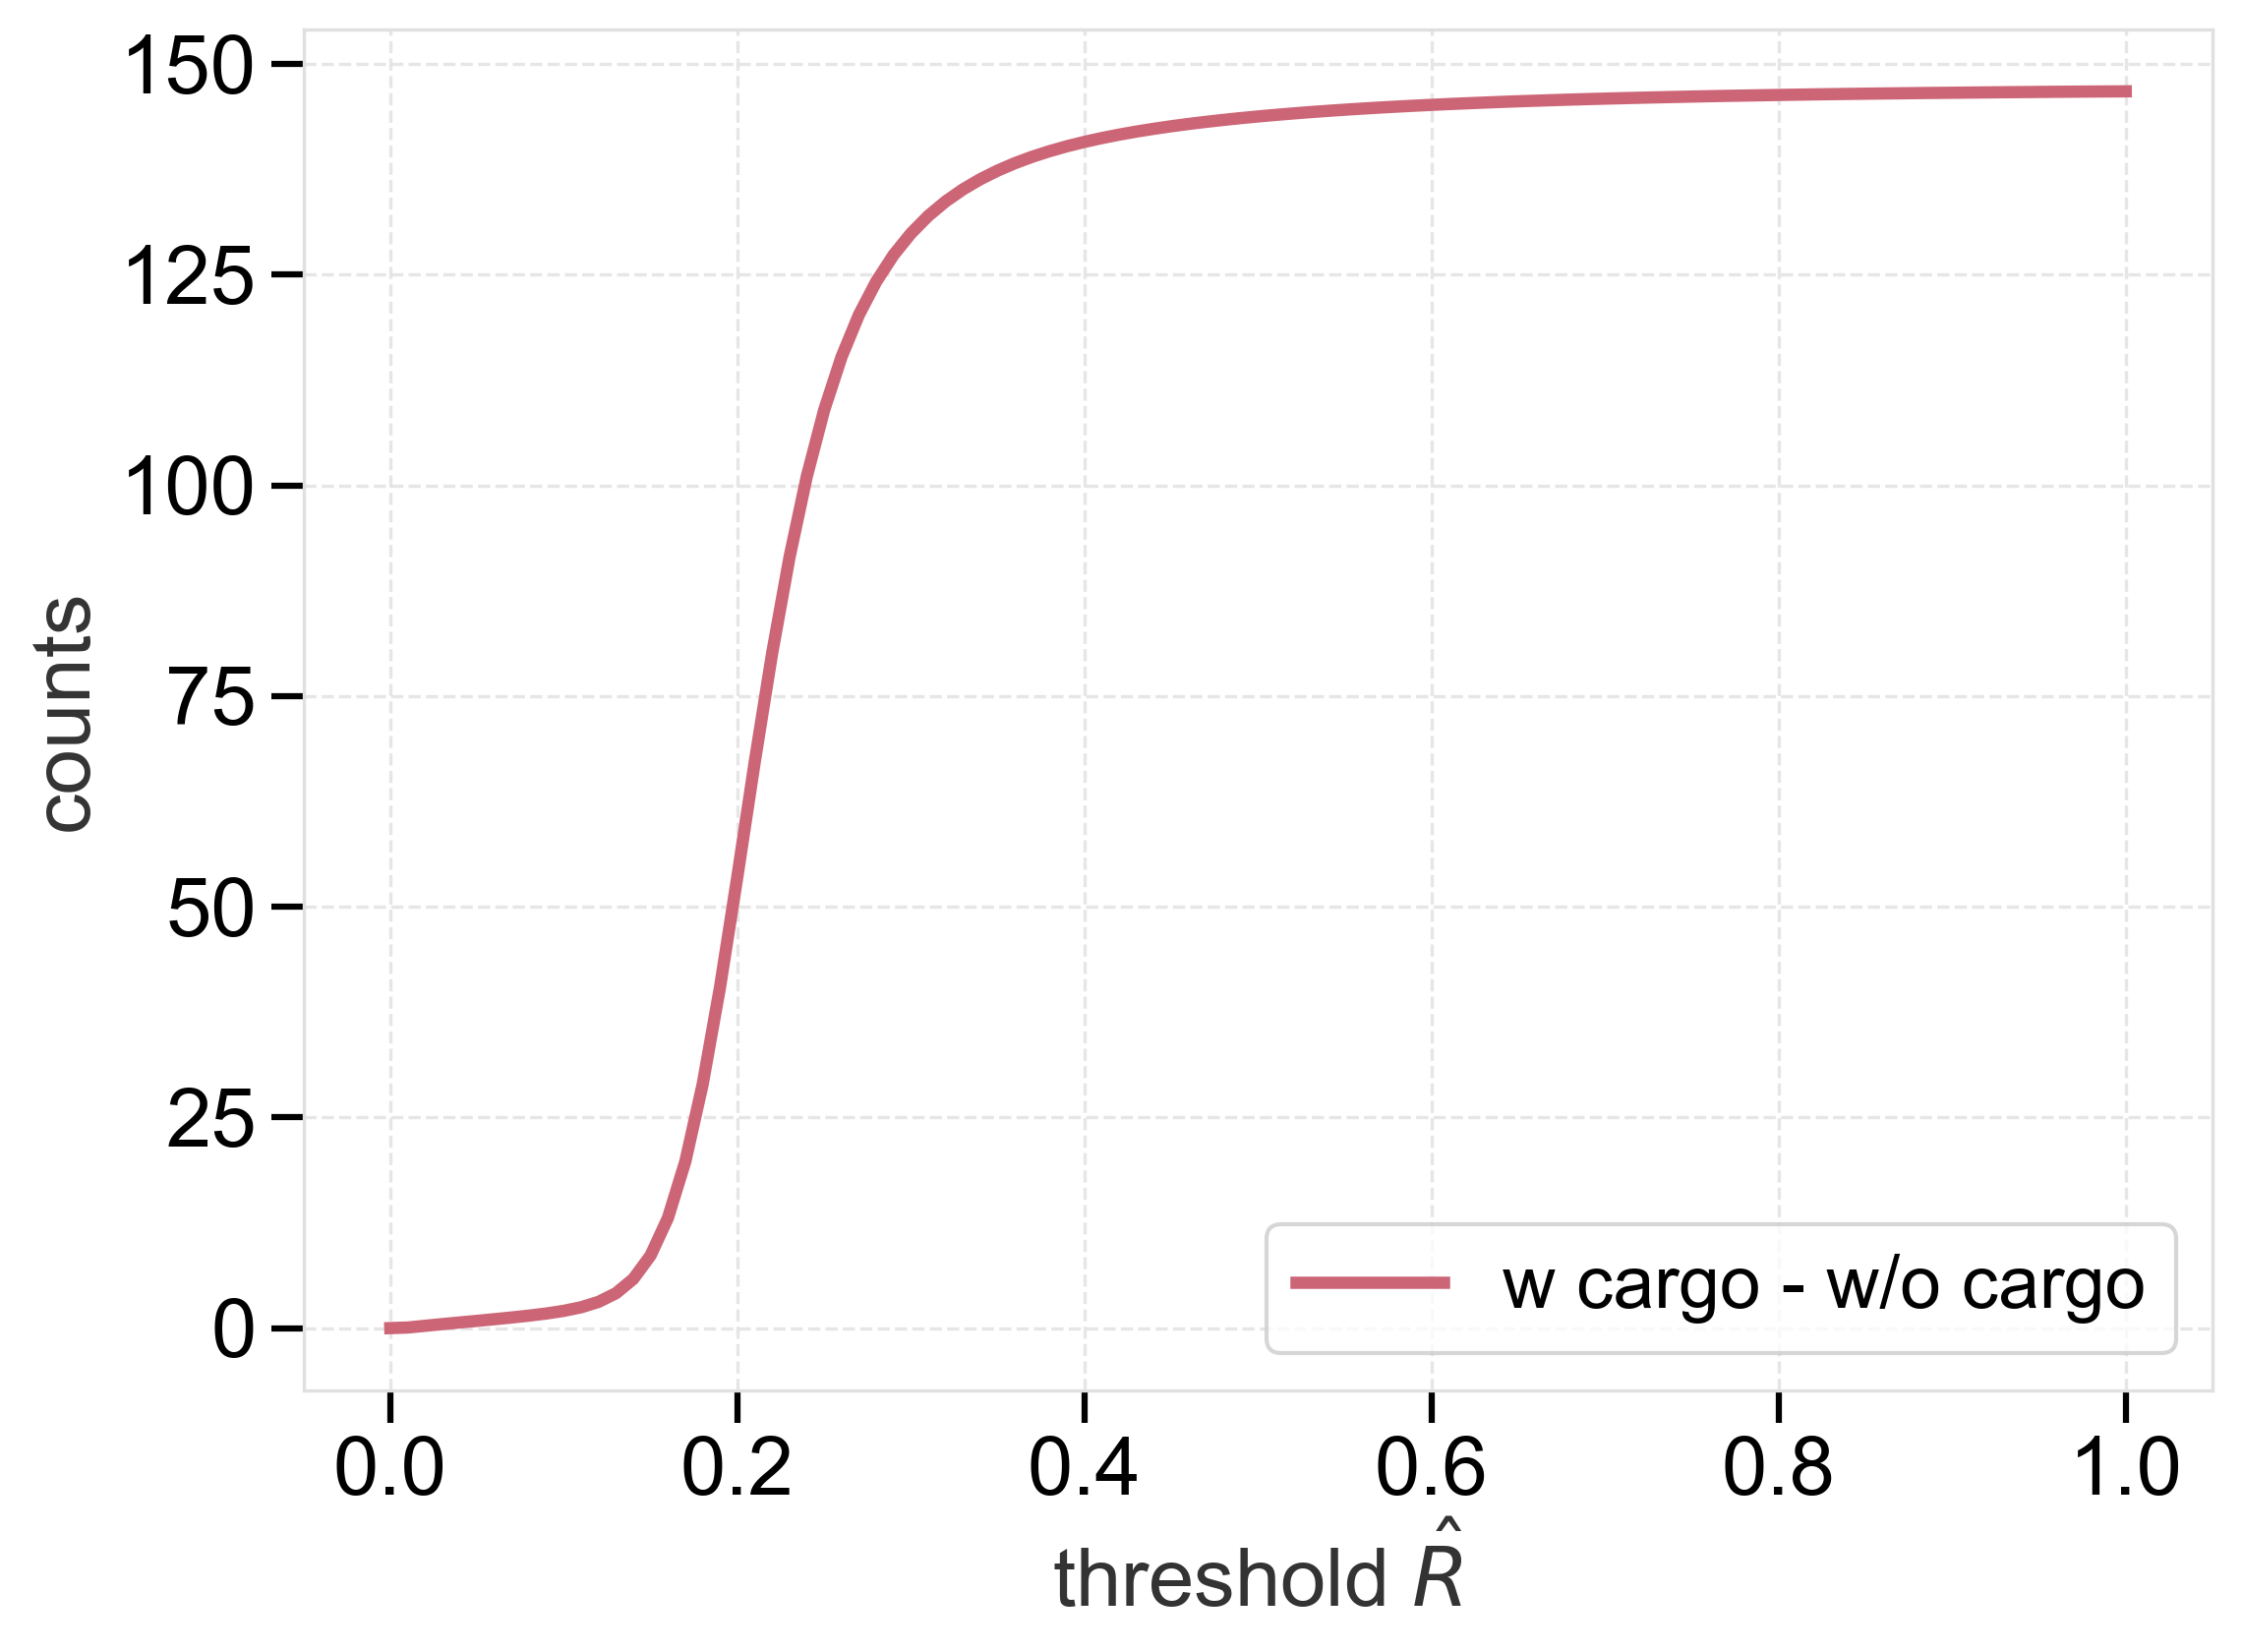

In [6]:
fig, ax = plt.subplots()

ax.plot(threshold, lcM-ccM, label = 'w cargo - w/o cargo')

ax.legend()

ax.set(xlabel = 'threshold $\hat{R}$',
       ylabel = 'counts')